# Emotion Labeling Tool

**Purpose:** Label child faces for emotion classification
**Labels:** Happy / Sad / Neutral
**Target:** 300 samples (100 per class)

## Step 1: Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import random
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets

print("✓ Setup complete")

Mounted at /content/drive
✓ Setup complete


## Step 2: Configuration

In [2]:
BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
CHILD_FOLDER = BASE_PATH / "classified/child"
GROUND_TRUTH_FOLDER = BASE_PATH / "ground_truth"
LABELS_FILE = GROUND_TRUTH_FOLDER / "emotion_labels_manual.csv"

GROUND_TRUTH_FOLDER.mkdir(exist_ok=True, parents=True)

# Targets
TARGET_HAPPY = 100
TARGET_SAD = 100
TARGET_NEUTRAL = 100

print(f"Child faces folder: {CHILD_FOLDER}")
print(f"Labels file: {LABELS_FILE}")
print(f"Target: {TARGET_HAPPY} happy + {TARGET_SAD} sad + {TARGET_NEUTRAL} neutral = 300")

Child faces folder: /content/drive/MyDrive/face_pipeline_project/classified/child
Labels file: /content/drive/MyDrive/face_pipeline_project/ground_truth/emotion_labels_manual.csv
Target: 100 happy + 100 sad + 100 neutral = 300


## Step 3: Collect All Child Faces

In [3]:
print("Collecting child face crops...")
all_crops = []

for video_folder in tqdm(list(CHILD_FOLDER.iterdir())):
    if video_folder.is_dir():
        for face_file in video_folder.glob("*.jpg"):
            all_crops.append({
                'video': video_folder.name,
                'face_file': face_file.name,
                'image_path': str(face_file)
            })

print(f"\nTotal child faces: {len(all_crops)}")

# Random shuffle
random.seed(42)
random.shuffle(all_crops)

df_crops = pd.DataFrame(all_crops)
print("✓ Randomly shuffled")

100%|██████████| 31/31 [00:06<00:00,  4.83it/s]


Total child faces: 6726
✓ Randomly shuffled


## Step 4: Load Previous Labels

In [4]:
if LABELS_FILE.exists():
    df_existing = pd.read_csv(LABELS_FILE)
    labeled_paths = set(df_existing['image_path'].tolist())

    happy_done = len(df_existing[df_existing['label'] == 'happy'])
    sad_done = len(df_existing[df_existing['label'] == 'sad'])
    neutral_done = len(df_existing[df_existing['label'] == 'neutral'])

    print(f"✓ Resuming:")
    print(f"  Happy: {happy_done}/{TARGET_HAPPY}")
    print(f"  Sad: {sad_done}/{TARGET_SAD}")
    print(f"  Neutral: {neutral_done}/{TARGET_NEUTRAL}")
else:
    df_existing = pd.DataFrame()
    labeled_paths = set()
    happy_done = 0
    sad_done = 0
    neutral_done = 0
    print("Starting fresh")

df_unlabeled = df_crops[~df_crops['image_path'].isin(labeled_paths)].reset_index(drop=True)
print(f"\nRemaining: {len(df_unlabeled)}")

Starting fresh

Remaining: 6726


## Step 5: Interactive Labeling Tool

══════════════════════════════════════════════════
Image 23/6726 | Session: 22
══════════════════════════════════════════════════

📊 Progress:
   😊 Happy:  [█░░░░░░░░░░░░░░░░░░░] 7/100 
   😢 Sad:    [░░░░░░░░░░░░░░░░░░░░] 3/100 
   😐 Neutral:[██░░░░░░░░░░░░░░░░░░] 12/100 



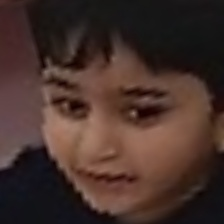

In [5]:
happy_count = happy_done
sad_count = sad_done
neutral_count = neutral_done
current_idx = [0]
session_labels = []

def save_labels():
    if session_labels:
        df_new = pd.DataFrame(session_labels)
        if LABELS_FILE.exists():
            df_old = pd.read_csv(LABELS_FILE)
            df_combined = pd.concat([df_old, df_new], ignore_index=True)
        else:
            df_combined = df_new
        df_combined.to_csv(LABELS_FILE, index=False)
        return len(df_combined)
    return happy_count + sad_count + neutral_count

def show_face(idx):
    global happy_count, sad_count, neutral_count
    clear_output(wait=True)

    # Check targets
    if happy_count >= TARGET_HAPPY and sad_count >= TARGET_SAD and neutral_count >= TARGET_NEUTRAL:
        save_labels()
        print("🎉 TARGET REACHED!")
        print(f"Happy: {happy_count} | Sad: {sad_count} | Neutral: {neutral_count}")
        print(f"Saved: {LABELS_FILE}")
        return

    if idx >= len(df_unlabeled):
        save_labels()
        print("✅ All labeled!")
        return

    row = df_unlabeled.iloc[idx]

    # Progress
    print(f"═" * 50)
    print(f"Image {idx + 1}/{len(df_unlabeled)} | Session: {len(session_labels)}")
    print(f"═" * 50)
    print(f"")
    print(f"📊 Progress:")

    def bar(count, target):
        filled = min(20, int(count/target*20)) if target > 0 else 0
        return '█' * filled + '░' * (20 - filled)

    print(f"   😊 Happy:  [{bar(happy_count, TARGET_HAPPY)}] {happy_count}/{TARGET_HAPPY} {'✅' if happy_count >= TARGET_HAPPY else ''}")
    print(f"   😢 Sad:    [{bar(sad_count, TARGET_SAD)}] {sad_count}/{TARGET_SAD} {'✅' if sad_count >= TARGET_SAD else ''}")
    print(f"   😐 Neutral:[{bar(neutral_count, TARGET_NEUTRAL)}] {neutral_count}/{TARGET_NEUTRAL} {'✅' if neutral_count >= TARGET_NEUTRAL else ''}")
    print(f"")

    # Image
    if Path(row['image_path']).exists():
        display(IPImage(filename=row['image_path']))
    else:
        print(f"❌ Not found")

    # Buttons
    btn_happy = widgets.Button(description="😊 HAPPY", button_style='success', layout=widgets.Layout(width='150px', height='50px'))
    btn_sad = widgets.Button(description="😢 SAD", button_style='danger', layout=widgets.Layout(width='150px', height='50px'))
    btn_neutral = widgets.Button(description="😐 NEUTRAL", button_style='warning', layout=widgets.Layout(width='150px', height='50px'))
    btn_skip = widgets.Button(description="Skip", layout=widgets.Layout(width='100px'))
    btn_back = widgets.Button(description="← Back", layout=widgets.Layout(width='100px'))
    btn_save = widgets.Button(description="💾 Save & Exit", button_style='info', layout=widgets.Layout(width='150px'))

    def add_label(label):
        global happy_count, sad_count, neutral_count
        session_labels.append({
            'video': row['video'],
            'face_file': row['face_file'],
            'image_path': row['image_path'],
            'label': label
        })
        if label == 'happy': happy_count += 1
        elif label == 'sad': sad_count += 1
        else: neutral_count += 1

        if len(session_labels) % 25 == 0: save_labels()

    def on_happy(b): add_label('happy'); current_idx[0] += 1; show_face(current_idx[0])
    def on_sad(b): add_label('sad'); current_idx[0] += 1; show_face(current_idx[0])
    def on_neutral(b): add_label('neutral'); current_idx[0] += 1; show_face(current_idx[0])
    def on_skip(b): current_idx[0] += 1; show_face(current_idx[0])
    def on_back(b):
        global happy_count, sad_count, neutral_count
        if current_idx[0] > 0 and session_labels:
            last = session_labels.pop()
            if last['label'] == 'happy': happy_count -= 1
            elif last['label'] == 'sad': sad_count -= 1
            else: neutral_count -= 1
            current_idx[0] -= 1
            show_face(current_idx[0])
    def on_save(b):
        save_labels()
        clear_output()
        print("💾 SAVED!")
        print(f"Happy: {happy_count} | Sad: {sad_count} | Neutral: {neutral_count}")

    btn_happy.on_click(on_happy); btn_sad.on_click(on_sad); btn_neutral.on_click(on_neutral)
    btn_skip.on_click(on_skip); btn_back.on_click(on_back); btn_save.on_click(on_save)

    display(widgets.HBox([btn_happy, btn_sad, btn_neutral]))
    display(widgets.HBox([btn_skip, btn_back, btn_save]))

print("🏁 Starting Emotion Labeling...")
show_face(0)

## Step 6: View Statistics

In [6]:
if LABELS_FILE.exists():
    df = pd.read_csv(LABELS_FILE)
    print(f"Total labeled: {len(df)}")
    print(f"\nBreakdown:")
    print(df['label'].value_counts())
else:
    print("No labels yet")

No labels yet


---
## ✅ Next Step

After labeling 300 samples, run the Emotion Fine-tuning notebook.